In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load dataset
df = pd.read_csv("GearsOfWar.csv")

# View first rows
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.363787e+09,253,i.imgur.com,1antn0,Oh the irony! (Gears: Judgement),Y2J7511,281,28,21,http://www.reddit.com/r/GearsOfWar/comments/1a...,NaN,NaN,False,http://a.thumbs.redditmedia.com/muVvMZFon2DfXe...,t5_2ruzg,False,NaN,NaN,False,t3_1antn0,http://i.imgur.com/Fo5d9Qh.jpg,NaN
1,1.353431e+09,241,imgur.com,13ilwm,"Saw this on Facebook, thought I'd share",nzeeshan,263,22,7,http://www.reddit.com/r/GearsOfWar/comments/13...,NaN,NaN,False,http://c.thumbs.redditmedia.com/6Z2gQAG982dhC_...,t5_2ruzg,False,NaN,NaN,False,t3_13ilwm,http://imgur.com/Q2hpA,NaN
2,1.320013e+09,171,i.imgur.com,lugn8,I saw r/gaming's new header for Battlefield an...,tronBeardsley,177,6,33,http://www.reddit.com/r/GearsOfWar/comments/lu...,NaN,NaN,False,default,t5_2ruzg,False,NaN,cogdizzybr,False,t3_lugn8,http://i.imgur.com/I2TZk.jpg,NaN
3,1.344018e+09,162,i.imgur.com,xmqhs,Check this new logo I made for you guys! What ...,TheRedditopiaNation,190,28,16,http://www.reddit.com/r/GearsOfWar/comments/xm...,NaN,NaN,False,http://d.thumbs.redditmedia.com/6SesRel9C1uZ2N...,t5_2ruzg,False,NaN,NaN,False,t3_xmqhs,http://i.imgur.com/fuqme.jpg,NaN
4,1.363663e+09,159,i.imgur.com,1akkrb,Gears of war launch event! What a line!,unspoken_Hero,177,18,45,http://www.reddit.com/r/GearsOfWar/comments/1a...,NaN,NaN,False,http://a.thumbs.redditmedia.com/ownGTnyWv_zUQ4...,t5_2ruzg,False,NaN,NaN,False,t3_1akkrb,http://i.imgur.com/8OrIEcE.jpg,NaN


In [3]:
# Dataset information
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  979 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                276 non-null    str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      21
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   724
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class     447
is_self                      0
name                         0
url                          0
distinguished              980
dtype: int64

In [4]:
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

In [6]:
df.columns.tolist()

['created_utc',
 'score',
 'domain',
 'id',
 'title',
 'author',
 'ups',
 'downs',
 'num_comments',
 'permalink',
 'selftext',
 'link_flair_text',
 'over_18',
 'thumbnail',
 'subreddit_id',
 'edited',
 'link_flair_css_class',
 'author_flair_css_class',
 'is_self',
 'name',
 'url',
 'distinguished']

In [9]:
print(df.head())
print(df.columns)

         id diagnosis  ...  fractal_dimension_worst  Unnamed: 32
0    842302         M  ...                  0.11890          NaN
1    842517         M  ...                  0.08902          NaN
2  84300903         M  ...                  0.08758          NaN
3  84348301         M  ...                  0.17300          NaN
4  84358402         M  ...                  0.07678          NaN

[5 rows x 33 columns]
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symm

In [11]:
print(locals())

{'__name__': '__main__', '__doc__': 'Automatically created module for IPython interactive environment', '__package__': None, '__loader__': None, '__spec__': None, '__builtin__': <module 'builtins' (built-in)>, '__builtins__': <module 'builtins' (built-in)>, '_ih': ['', 'import pandas as pd\nimport numpy as np\n\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import accuracy_score, classification_report, confusion_matrix\nfrom sklearn.preprocessing import LabelEncoder', '# Load dataset\ndf = pd.read_csv("GearsOfWar.csv")\n\n# View first rows\ndf.head()', '# Dataset information\ndf.info()\n\n# Summary statistics\ndf.describe()\n\n# Check missing values\ndf.isnull().sum()', "label_encoder = LabelEncoder()\n\nfor column in df.columns:\n    if df[column].dtype == 'object':\n        df[column] = label_encoder.fit_transform(df[column])", 'X = df.drop("Target", axis=1)\ny = df["Target"]', 'df.columns.tolist()', 'X

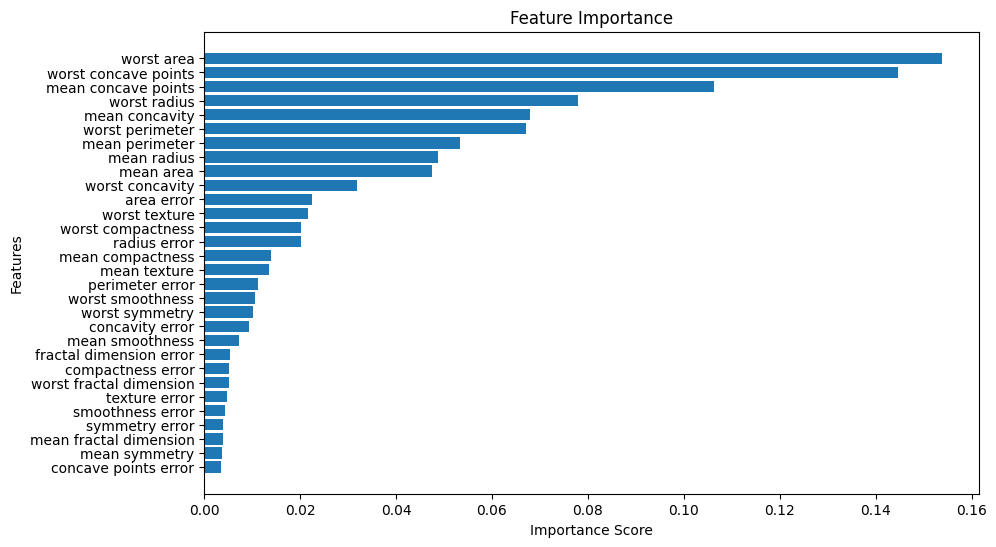

In [17]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Example: load dataset
# Replace this with your own dataset if you already have one
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

# Create dataframe
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance
importances = rf_model.feature_importances_
features = X.columns

# Sort importance
indices = np.argsort(importances)

# Plot Feature Importance
plt.figure(figsize=(10,6))
plt.title("Feature Importance")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), features[indices])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()